In [1]:
# Import reusable segmentation code

import sys
import importlib
from pathlib import Path

CODE_DIR = Path("/content/drive/MyDrive/ASR_Project/ASR_finalproject_AllisonWivagg_YeritmaryR/FINAL_Codes")

if str(CODE_DIR) not in sys.path:
    sys.path.append(str(CODE_DIR))

import segmentation
importlib.reload(segmentation)
from segmentation import *

print("segmentation.py imported successfully")
print("MC dropout function available:", "makeActiveSubsetMCDropout" in globals())


segmentation.py imported successfully
MC dropout function available: True


In [2]:
# Set up paths and check data 

ROOT = Path("/content/drive/MyDrive/ASR_Project/ASR_finalproject_AllisonWivagg_YeritmaryR")

DATA_DIR = ROOT / "data"
OUT_DIR = ROOT / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

B039_IMG = DATA_DIR / "b039" / "images"
B039_MASK = DATA_DIR / "b039" / "masks"

print("B039_IMG exists:", B039_IMG.exists())
print("B039_MASK exists:", B039_MASK.exists())

print("number images:", len(listimgs(B039_IMG)))
print("number masks:", len(listimgs(B039_MASK)))

B039_IMG exists: True
B039_MASK exists: True
number images: 200
number masks: 200


In [3]:
# Set random seeds and device

seeds = [42, 7, 123]
for seed in seeds:
    setSeed(seed)
    print("Running seed:", seed)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)

Running seed: 42
Running seed: 7
Running seed: 123
Using device: cuda


In [4]:
# Pairing the image and mask files to create a DataFrame for the BBBC039 dataset

b039Table = pairFiles(B039_IMG, B039_MASK, "BBBC039")

print("Matched image and mask pairs:", len(b039Table))
print(b039Table.head())

Matched image and mask pairs: 200
                                            image_id  \
0  IXMtest_A02_s1_w1051DAA7C-7042-435F-99F0-1E847...   
1  IXMtest_A06_s6_w1B9577918-4973-4A87-BA73-A168A...   
2  IXMtest_A09_s1_w1CE70AD49-290D-4312-82E6-CDC71...   
3  IXMtest_A12_s7_w1EAEEA614-51ED-43B3-A4FF-08873...   
4  IXMtest_A15_s5_w1825174D4-ED30-490C-9635-61964...   

                                          image_path  \
0  /content/drive/MyDrive/ASR_Project/ASR_finalpr...   
1  /content/drive/MyDrive/ASR_Project/ASR_finalpr...   
2  /content/drive/MyDrive/ASR_Project/ASR_finalpr...   
3  /content/drive/MyDrive/ASR_Project/ASR_finalpr...   
4  /content/drive/MyDrive/ASR_Project/ASR_finalpr...   

                                           mask_path   source  
0  /content/drive/MyDrive/ASR_Project/ASR_finalpr...  BBBC039  
1  /content/drive/MyDrive/ASR_Project/ASR_finalpr...  BBBC039  
2  /content/drive/MyDrive/ASR_Project/ASR_finalpr...  BBBC039  
3  /content/drive/MyDrive/ASR_Projec

In [5]:
# Split data into training, validation, and test tables

trainingTable, validationTable, testTable = splitData(
    b039Table,
    seed=seed,
    trainSize=0.70,
    validationSize=0.15,
    testSize=0.15
)

print("training size:", len(trainingTable))
print("validation size:", len(validationTable))
print("test size:", len(testTable))

training size: 139
validation size: 30
test size: 31


In [6]:
# Create full segmentation datasets for training, validation, and testing using the SegSet class

trainingSet = SegSet(trainingTable, size=(256, 256), mode="gray")
validationSet = SegSet(validationTable, size=(256, 256), mode="gray")
testSet = SegSet(testTable, size=(256, 256), mode="gray")

print("training dataset size:", len(trainingSet))
print("validation dataset size:", len(validationSet))
print("test dataset size:", len(testSet))

training dataset size: 139
validation dataset size: 30
test dataset size: 31


image shape: torch.Size([1, 256, 256])
mask shape: torch.Size([1, 256, 256])
image id: IXMtest_I15_s5_w11265571E-AA95-4E58-82CF-A75E3F240956
source: BBBC039
split: train


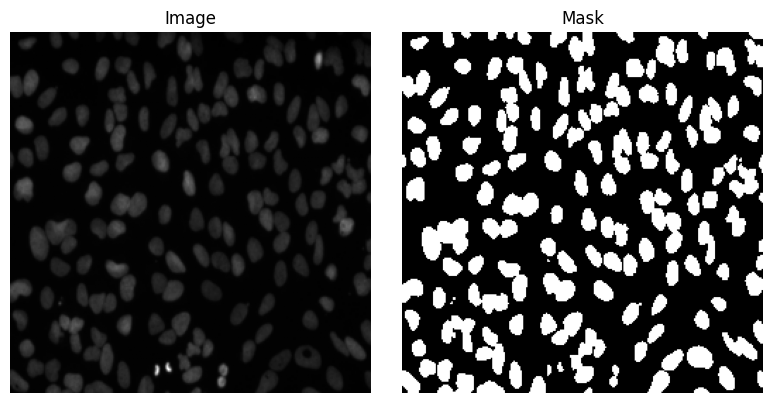

In [7]:
# Check one image-mask pair

sample = trainingSet[0]

print("image shape:", sample["image"].shape)
print("mask shape:", sample["mask"].shape)
print("image id:", sample["image_id"])
print("source:", sample["source"])
print("split:", sample["split"])

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(sample["image"].squeeze().numpy(), cmap="gray")
plt.title("Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sample["mask"].squeeze().numpy(), cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
# Passive learning subset creation function

def makePassiveSubset(dataset, numberOfSamples=120, seed=seed):
    setSeed(seed)

    allIndexes = list(range(len(dataset)))
    random.shuffle(allIndexes)

    selectedIndexes = allIndexes[:numberOfSamples]

    subset = torch.utils.data.Subset(dataset, selectedIndexes)

    return subset, selectedIndexes

In [9]:
# Create passive learning subset

passiveTrainingSet, passiveIndexes = makePassiveSubset(
    dataset=trainingSet,
    numberOfSamples=120,
    seed=seed
)

print("passive training size:", len(passiveTrainingSet))
print("first passive indexes:", passiveIndexes[:10])

passive training size: 120
first passive indexes: [52, 101, 7, 69, 126, 51, 103, 74, 133, 131]


In [10]:
#  small warm up set for active learning

warmupTrainingSet, warmupIndexes = makePassiveSubset(
    dataset=trainingSet,
    numberOfSamples=40,
    seed=seed
)

warmupTrainingLoader = makeLoader(
    warmupTrainingSet,
    batchSize=4,
    shuffle=True
)

validationLoader = makeLoader(
    validationSet,
    batchSize=4,
    shuffle=False
)

print("warm-up training size:", len(warmupTrainingSet))

warm-up training size: 40


In [11]:
# Train the small set model before active selection

warmupNetwork = UNet(
    inputChannels=1,
    outputChannels=1,
    dropoutRate=0.3
).to(DEVICE)

warmupTrainedNetwork, warmupHistoryTable = trainNetwork(
    network=warmupNetwork,
    trainingLoader=warmupTrainingLoader,
    validationLoader=validationLoader,
    device=DEVICE,
    numEpochs=5,
    learningRate=1e-3,
    savingPath=None
)

warmupHistoryTable

Epoch 1/5 | Batch 1/10 | Loss: 1.3855
Epoch 1/5 | Train Loss: 1.1325 | Validation Loss: 1.2808 | Validation Dice: 0.3710 | Validation IoU: 0.2761
Epoch 2/5 | Batch 1/10 | Loss: 0.8950
Epoch 2/5 | Train Loss: 0.8765 | Validation Loss: 1.2020 | Validation Dice: 0.5603 | Validation IoU: 0.4024
Epoch 3/5 | Batch 1/10 | Loss: 0.8483
Epoch 3/5 | Train Loss: 0.7921 | Validation Loss: 1.3154 | Validation Dice: 0.4386 | Validation IoU: 0.2905
Epoch 4/5 | Batch 1/10 | Loss: 0.7400
Epoch 4/5 | Train Loss: 0.7437 | Validation Loss: 0.9495 | Validation Dice: 0.6890 | Validation IoU: 0.5395
Epoch 5/5 | Batch 1/10 | Loss: 0.6547
Epoch 5/5 | Train Loss: 0.6768 | Validation Loss: 0.7168 | Validation Dice: 0.8666 | Validation IoU: 0.7650


,epoch,trainLoss,validationLoss,validationDice,validationIoU
0,1,1.132496,1.280768,0.370959,0.276105
1,2,0.876452,1.201953,0.560330,0.402406
2,3,0.792115,1.315361,0.438599,0.290521
3,4,0.743725,0.949537,0.689024,0.539518
4,5,0.676804,0.716831,0.866599,0.765026


In [12]:
# Creating the active learning subset using MC dropout uncertainty

activeTrainingSet, activeIndexes, uncertaintyTable = makeActiveSubsetMCDropout(
    dataset=trainingSet,
    trainedNetwork=warmupTrainedNetwork,
    device=DEVICE,
    warmupIndexes=warmupIndexes,
    numberOfSamples=120,
    batchSize=16,
    numMCSamples=5
)

print("active training size:", len(activeTrainingSet))
print("first active indexes:", activeIndexes[:10])
print(uncertaintyTable.head().to_string(index=False))


active training size: 120
first active indexes: [52, 101, 7, 69, 126, 51, 103, 74, 133, 131]
 index  uncertainty
     2     0.110679
    89     0.034633
    42     0.031398
    40     0.030133
    93     0.029806


In [13]:
# Train passive model

passiveTrainingLoader = makeLoader(
    passiveTrainingSet,
    batchSize=4,
    shuffle=True
)

validationLoader = makeLoader(
    validationSet,
    batchSize=4,
    shuffle=False
)

passiveNetwork = UNet(
    inputChannels=1,
    outputChannels=1,
    dropoutRate=0.3
).to(DEVICE)

passiveTrainedNetwork, passiveHistoryTable = trainNetwork(
    network=passiveNetwork,
    trainingLoader=passiveTrainingLoader,
    validationLoader=validationLoader,
    device=DEVICE,
    numEpochs=5,
    learningRate=1e-3,
    savingPath=None
)

passiveHistoryTable

Epoch 1/5 | Batch 1/30 | Loss: 1.6346
Epoch 1/5 | Batch 11/30 | Loss: 0.9481
Epoch 1/5 | Batch 21/30 | Loss: 0.6958
Epoch 1/5 | Train Loss: 0.9591 | Validation Loss: 0.7645 | Validation Dice: 0.8698 | Validation IoU: 0.7726
Epoch 2/5 | Batch 1/30 | Loss: 0.7499
Epoch 2/5 | Batch 11/30 | Loss: 0.5898
Epoch 2/5 | Batch 21/30 | Loss: 0.5813
Epoch 2/5 | Train Loss: 0.6687 | Validation Loss: 0.4864 | Validation Dice: 0.9271 | Validation IoU: 0.8644
Epoch 3/5 | Batch 1/30 | Loss: 0.5334
Epoch 3/5 | Batch 11/30 | Loss: 0.4496
Epoch 3/5 | Batch 21/30 | Loss: 0.5082
Epoch 3/5 | Train Loss: 0.5195 | Validation Loss: 0.3662 | Validation Dice: 0.9223 | Validation IoU: 0.8565
Epoch 4/5 | Batch 1/30 | Loss: 0.3232
Epoch 4/5 | Batch 11/30 | Loss: 0.4021
Epoch 4/5 | Batch 21/30 | Loss: 0.4018
Epoch 4/5 | Train Loss: 0.4285 | Validation Loss: 0.2898 | Validation Dice: 0.9475 | Validation IoU: 0.9004
Epoch 5/5 | Batch 1/30 | Loss: 0.3599
Epoch 5/5 | Batch 11/30 | Loss: 0.3882
Epoch 5/5 | Batch 21/30 | L

,epoch,trainLoss,validationLoss,validationDice,validationIoU
0,1,0.959066,0.764518,0.869830,0.772621
1,2,0.668733,0.486364,0.927148,0.864429
2,3,0.519468,0.366193,0.922303,0.856517
3,4,0.428549,0.289808,0.947482,0.900391
4,5,0.371841,0.221164,0.957496,0.918757


In [14]:
# Train active model

activeTrainingLoader = makeLoader(
    activeTrainingSet,
    batchSize=4,
    shuffle=True
)

activeNetwork = UNet(
    inputChannels=1,
    outputChannels=1,
    dropoutRate=0.3
).to(DEVICE)

activeTrainedNetwork, activeHistoryTable = trainNetwork(
    network=activeNetwork,
    trainingLoader=activeTrainingLoader,
    validationLoader=validationLoader,
    device=DEVICE,
    numEpochs=5,
    learningRate=1e-3,
    savingPath=None
)

activeHistoryTable

Epoch 1/5 | Batch 1/30 | Loss: 1.3107
Epoch 1/5 | Batch 11/30 | Loss: 0.9758
Epoch 1/5 | Batch 21/30 | Loss: 0.7430
Epoch 1/5 | Train Loss: 0.9250 | Validation Loss: 0.9692 | Validation Dice: 0.7036 | Validation IoU: 0.5476
Epoch 2/5 | Batch 1/30 | Loss: 0.7360
Epoch 2/5 | Batch 11/30 | Loss: 0.6786
Epoch 2/5 | Batch 21/30 | Loss: 0.6371
Epoch 2/5 | Train Loss: 0.7149 | Validation Loss: 0.6251 | Validation Dice: 0.8777 | Validation IoU: 0.7825
Epoch 3/5 | Batch 1/30 | Loss: 0.6073
Epoch 3/5 | Batch 11/30 | Loss: 0.5865
Epoch 3/5 | Batch 21/30 | Loss: 0.7038
Epoch 3/5 | Train Loss: 0.5995 | Validation Loss: 0.3938 | Validation Dice: 0.9281 | Validation IoU: 0.8661
Epoch 4/5 | Batch 1/30 | Loss: 0.4067
Epoch 4/5 | Batch 11/30 | Loss: 0.5226
Epoch 4/5 | Batch 21/30 | Loss: 0.3832
Epoch 4/5 | Train Loss: 0.5096 | Validation Loss: 0.3373 | Validation Dice: 0.9331 | Validation IoU: 0.8748
Epoch 5/5 | Batch 1/30 | Loss: 0.3106
Epoch 5/5 | Batch 11/30 | Loss: 0.3387
Epoch 5/5 | Batch 21/30 | L

,epoch,trainLoss,validationLoss,validationDice,validationIoU
0,1,0.925006,0.969165,0.703635,0.547559
1,2,0.714896,0.625058,0.877655,0.782454
2,3,0.599524,0.393817,0.928093,0.866078
3,4,0.509553,0.337340,0.933091,0.874837
4,5,0.413777,0.258131,0.951511,0.907674


In [15]:
# Evaluate passive and active models on the same test set

testLoader = makeLoader(testSet, batchSize=4, shuffle=False)

lossFunction = SegLoss()

passiveTestResults = evaluateNetwork(
    network=passiveTrainedNetwork,
    dataLoader=testLoader,
    lossFunction=lossFunction,
    device=DEVICE
)

activeTestResults = evaluateNetwork(
    network=activeTrainedNetwork,
    dataLoader=testLoader,
    lossFunction=lossFunction,
    device=DEVICE
)

print("Passive test results:")
print(passiveTestResults)

print("\nActive test results:")
print(activeTestResults)

Passive test results:
{'loss': 0.22624717839062214, 'dice': 0.9568266719579697, 'iou': 0.9181577637791634}

Active test results:
{'loss': 0.26328145526349545, 'dice': 0.9503282010555267, 'iou': 0.9062683209776878}


In [16]:
# Compare passive and active learning results

comparisonTable = pd.DataFrame([
    {
        "dataset": "BBBC039",
        "strategy": "passive",
        "training_samples": len(passiveTrainingSet),
        "test_loss": passiveTestResults["loss"],
        "test_dice": passiveTestResults["dice"],
        "test_iou": passiveTestResults["iou"]
    },
    {
        "dataset": "BBBC039",
        "strategy": "active",
        "training_samples": len(activeTrainingSet),
        "test_loss": activeTestResults["loss"],
        "test_dice": activeTestResults["dice"],
        "test_iou": activeTestResults["iou"]
    }
])

print(comparisonTable.to_string(index=False))

dataset strategy  training_samples  test_loss  test_dice  test_iou
BBBC039  passive               120   0.226247   0.956827  0.918158
BBBC039   active               120   0.263281   0.950328  0.906268


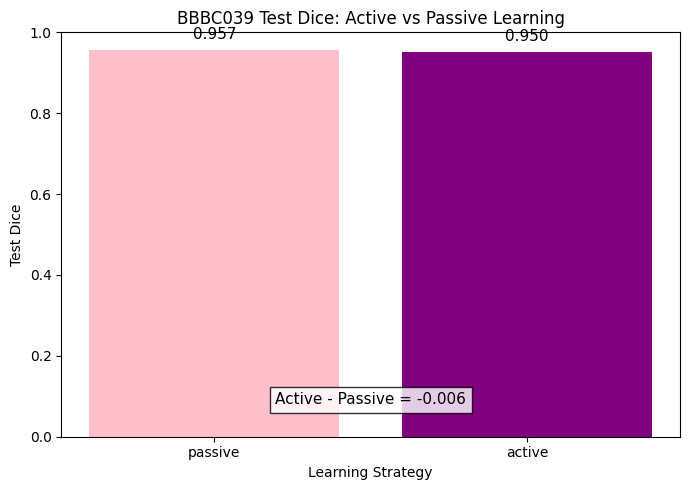

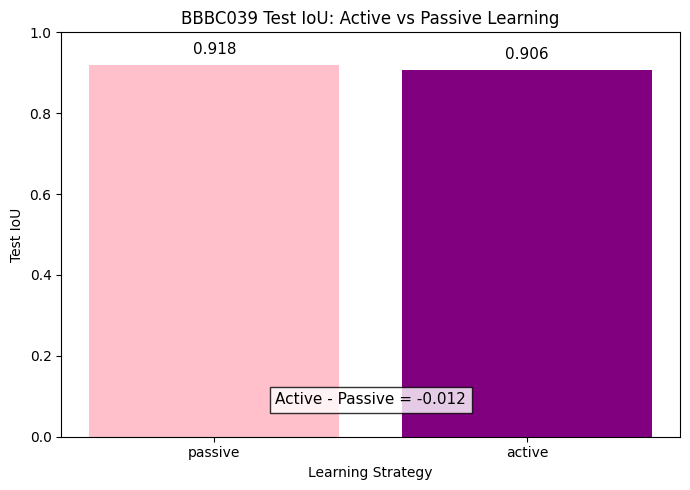

In [17]:
#  Dice and IoU comparison plots for BBBC039

barColors = ["pink", "purple"]

metrics = [
    ("test_dice", "Dice"),
    ("test_iou", "IoU")
]

for metricColumn, metricName in metrics:
    passiveValue = comparisonTable.loc[
        comparisonTable["strategy"] == "passive", metricColumn
    ].iloc[0]

    activeValue = comparisonTable.loc[
        comparisonTable["strategy"] == "active", metricColumn
    ].iloc[0]

    difference = activeValue - passiveValue

    plt.figure(figsize=(7, 5))

    bars = plt.bar(
        comparisonTable["strategy"],
        comparisonTable[metricColumn],
        color=barColors
    )

    plt.ylabel(f"Test {metricName}")
    plt.xlabel("Learning Strategy")
    plt.title(f"BBBC039 Test {metricName}: Active vs Passive Learning")
    plt.ylim(0, 1)

    # Adding the  values above bars
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.02,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=11
        )

    
    plt.text(
        0.5,
        0.08,
        f"Active - Passive = {difference:+.3f}",
        ha="center",
        fontsize=11,
        bbox=dict(facecolor="white", alpha=0.8)
    )

    plt.tight_layout()
    plt.show()

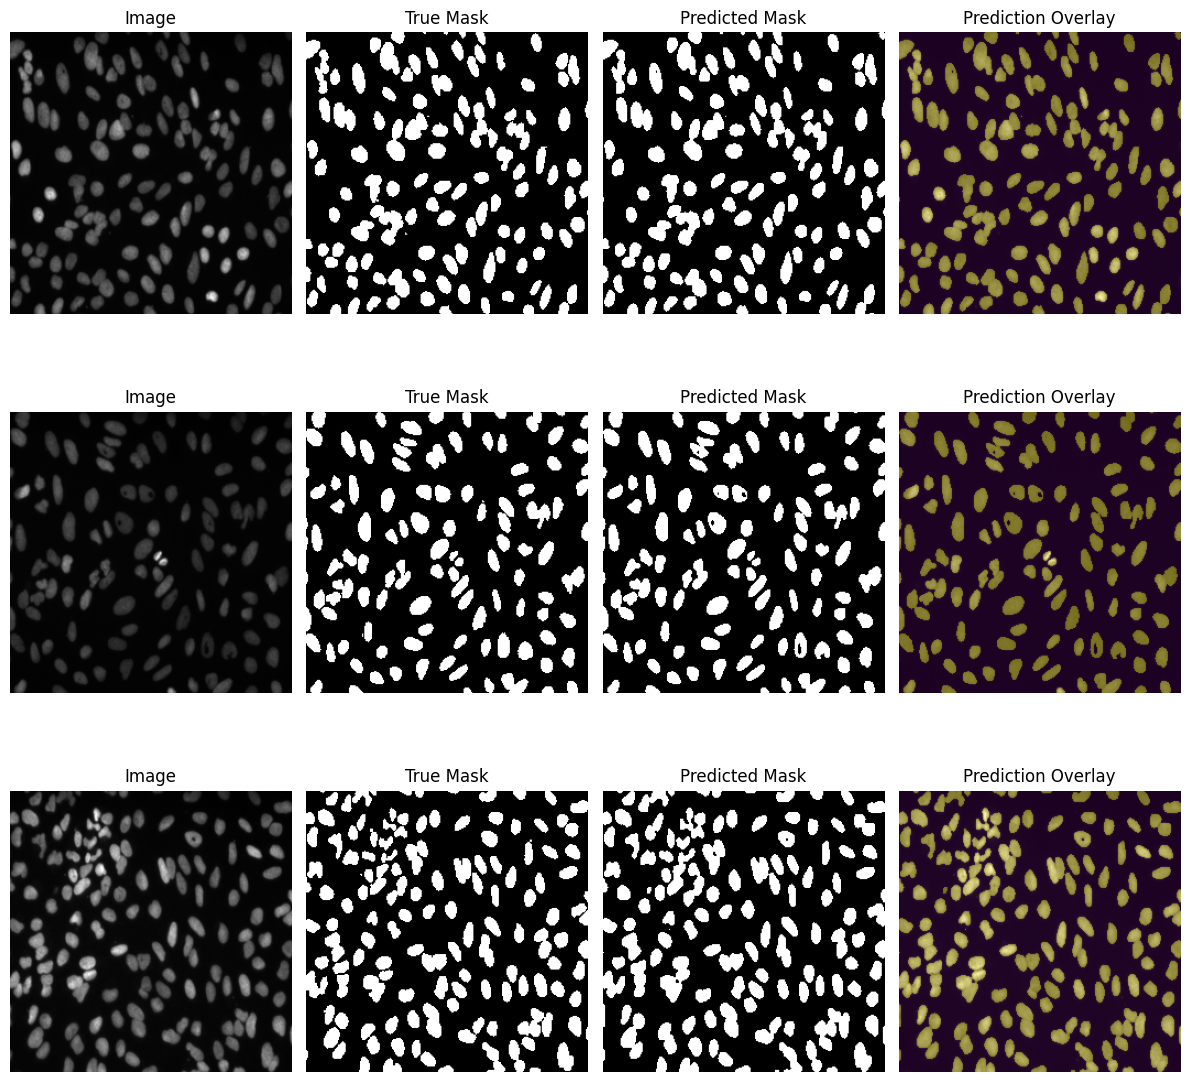

In [18]:
# Show passive model predictions

showPredictions(
    network=passiveTrainedNetwork,
    dataset=testSet,
    device=DEVICE,
    numberOfImages=3,
    threshold=0.5
)

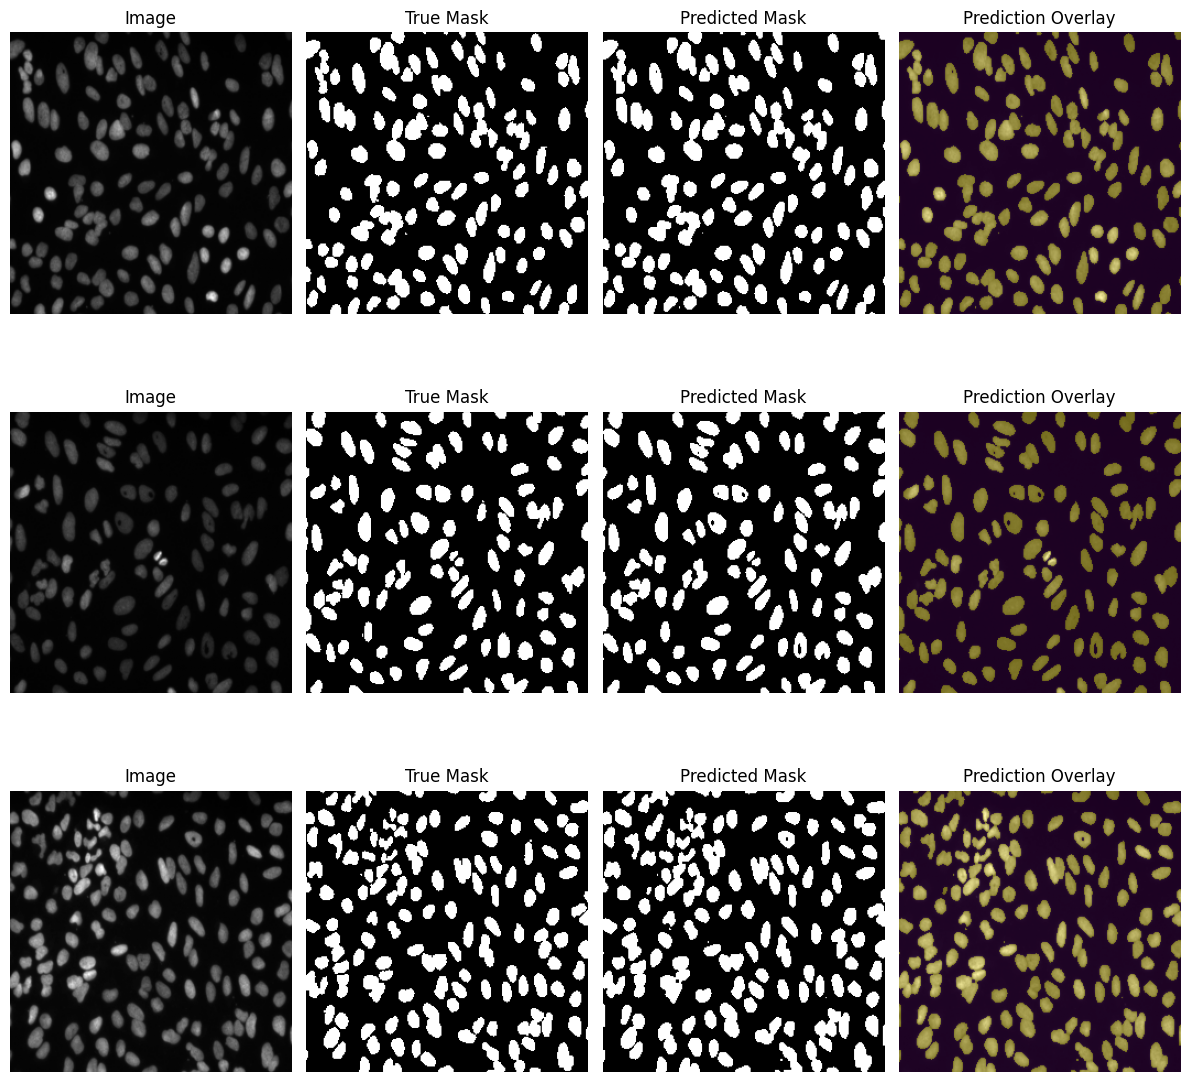

In [19]:
# Show active model predictions

showPredictions(
    network=activeTrainedNetwork,
    dataset=testSet,
    device=DEVICE,
    numberOfImages=3,
    threshold=0.5
)

In [20]:
# Save BBBC039 active/passive comparison results

bbbc039ComparisonPath = OUT_DIR / "BBBC039_active_passive_comparison.csv"
comparisonTable.to_csv(bbbc039ComparisonPath, index=False)

passiveHistoryPath = OUT_DIR / "BBBC039_passive_history.csv"
activeHistoryPath = OUT_DIR / "BBBC039_active_history.csv"
warmupHistoryPath = OUT_DIR / "BBBC039_warmup_history.csv"

passiveHistoryTable.to_csv(passiveHistoryPath, index=False)
activeHistoryTable.to_csv(activeHistoryPath, index=False)
warmupHistoryTable.to_csv(warmupHistoryPath, index=False)

print("Saved comparison table to:", bbbc039ComparisonPath)
print("Saved passive history to:", passiveHistoryPath)
print("Saved active history to:", activeHistoryPath)
print("Saved warm-up history to:", warmupHistoryPath)

Saved comparison table to: /content/drive/MyDrive/ASR_Project/ASR_finalproject_AllisonWivagg_YeritmaryR/outputs/BBBC039_active_passive_comparison.csv
Saved passive history to: /content/drive/MyDrive/ASR_Project/ASR_finalproject_AllisonWivagg_YeritmaryR/outputs/BBBC039_passive_history.csv
Saved active history to: /content/drive/MyDrive/ASR_Project/ASR_finalproject_AllisonWivagg_YeritmaryR/outputs/BBBC039_active_history.csv
Saved warm-up history to: /content/drive/MyDrive/ASR_Project/ASR_finalproject_AllisonWivagg_YeritmaryR/outputs/BBBC039_warmup_history.csv


In [21]:
# Compare ground truth, passive prediction, and active prediction on the same test images

def calculateSingleImageMetrics(predictedMask, trueMask, epsilon=1e-7):
    predictedMask = predictedMask.astype(np.float32)
    trueMask = trueMask.astype(np.float32)

    intersection = np.sum(predictedMask * trueMask)
    predictedArea = np.sum(predictedMask)
    trueArea = np.sum(trueMask)
    union = predictedArea + trueArea - intersection

    dice = (2 * intersection + epsilon) / (predictedArea + trueArea + epsilon)
    iou = (intersection + epsilon) / (union + epsilon)

    return dice, iou


def showPassiveActiveComparison(
    passiveNetwork,
    activeNetwork,
    dataset,
    device,
    numberOfImages=3,
    threshold=0.5,
    figureTitle="Passive vs Active Prediction Comparison"
):
    passiveNetwork.eval()
    activeNetwork.eval()

    plt.figure(figsize=(16, 4 * numberOfImages))

    for imageIndex in range(numberOfImages):
        sample = dataset[imageIndex]

        imageTensor = sample["image"].unsqueeze(0).to(device)
        imageToShow = sample["image"].squeeze().cpu().numpy()
        trueMask = sample["mask"].squeeze().cpu().numpy()

        with torch.no_grad():
            passiveLogits = passiveNetwork(imageTensor)
            passiveProbabilities = torch.sigmoid(passiveLogits)
            passiveMask = passiveProbabilities.squeeze().cpu().numpy()
            passiveBinaryMask = (passiveMask > threshold).astype(np.float32)

            activeLogits = activeNetwork(imageTensor)
            activeProbabilities = torch.sigmoid(activeLogits)
            activeMask = activeProbabilities.squeeze().cpu().numpy()
            activeBinaryMask = (activeMask > threshold).astype(np.float32)

        passiveDice, passiveIoU = calculateSingleImageMetrics(
            passiveBinaryMask,
            trueMask
        )

        activeDice, activeIoU = calculateSingleImageMetrics(
            activeBinaryMask,
            trueMask
        )

        # Column 1: original image
        plt.subplot(numberOfImages, 4, imageIndex * 4 + 1)
        plt.imshow(imageToShow, cmap="gray")
        plt.title("Image")
        plt.axis("off")

        # Column 2: ground truth
        plt.subplot(numberOfImages, 4, imageIndex * 4 + 2)
        plt.imshow(trueMask, cmap="gray")
        plt.title("Ground Truth Mask")
        plt.axis("off")

        # Column 3: passive predicted mask
        plt.subplot(numberOfImages, 4, imageIndex * 4 + 3)
        plt.imshow(passiveBinaryMask, cmap="gray")
        plt.title(
            f"Passive Prediction\nDice={passiveDice:.3f}, IoU={passiveIoU:.3f}"
        )
        plt.axis("off")

        # Column 4: active predicted mask
        plt.subplot(numberOfImages, 4, imageIndex * 4 + 4)
        plt.imshow(activeBinaryMask, cmap="gray")
        plt.title(
            f"Active Prediction\nDice={activeDice:.3f}, IoU={activeIoU:.3f}"
        )
        plt.axis("off")

    plt.suptitle(figureTitle, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

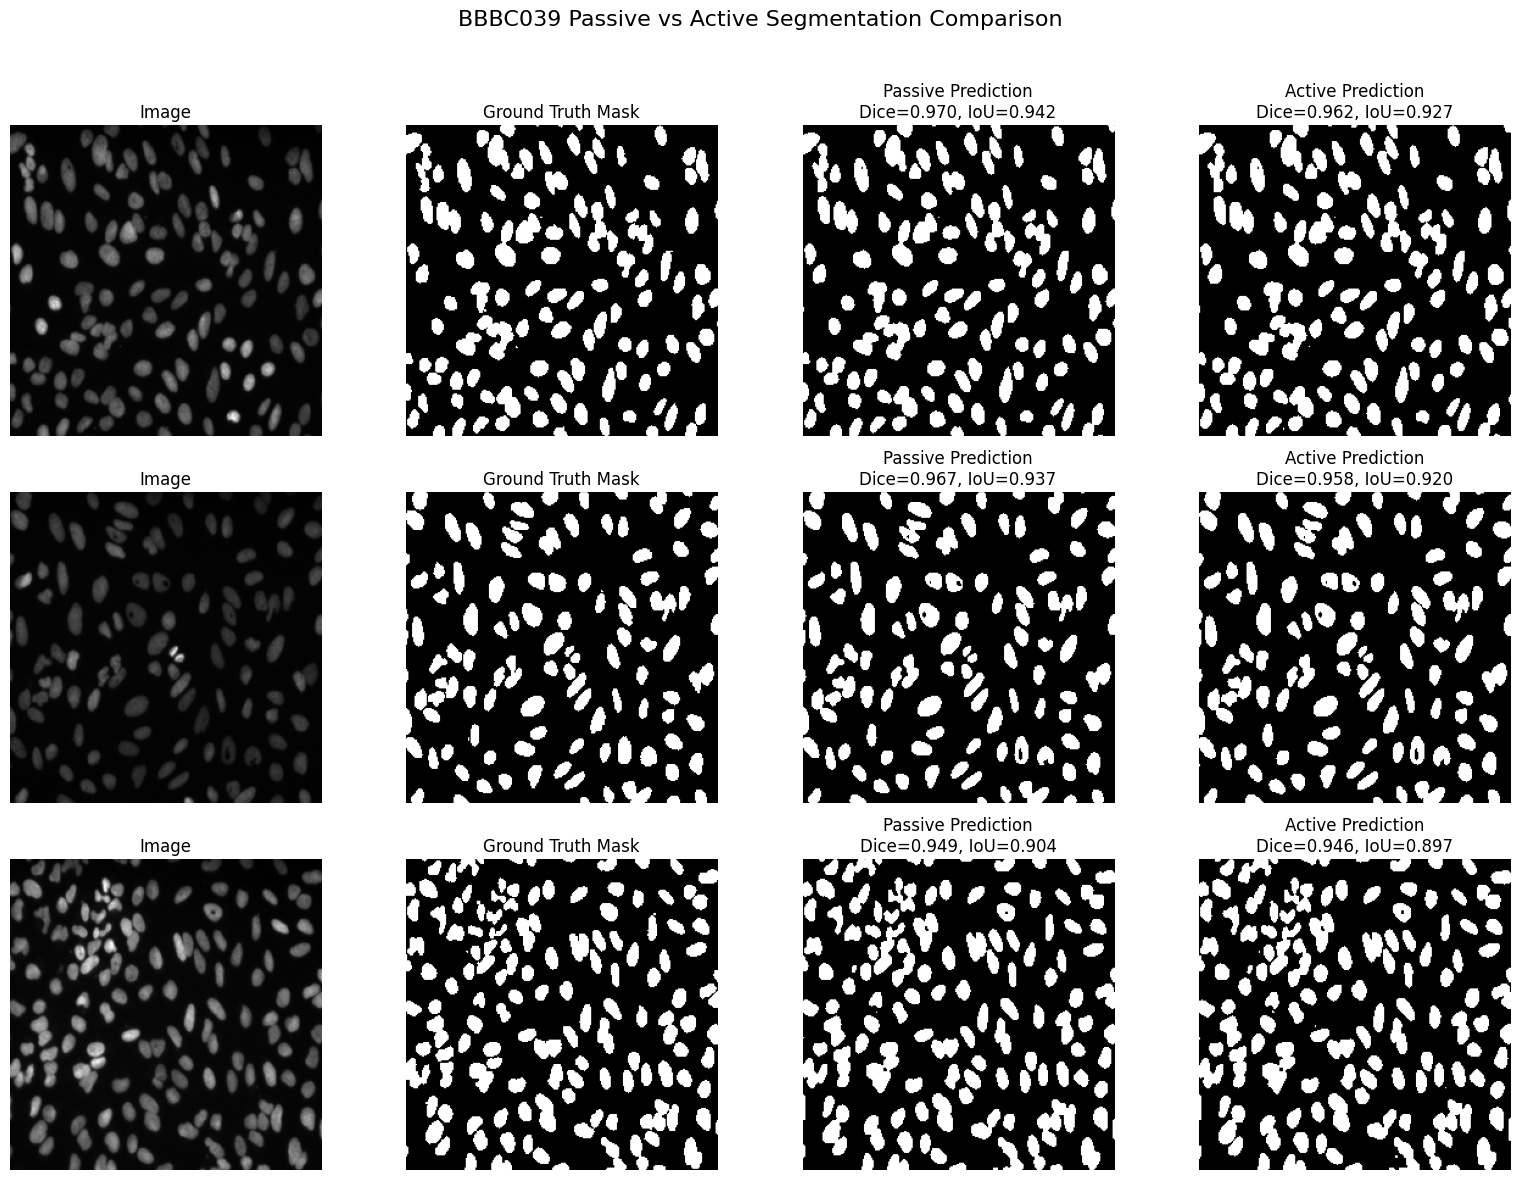

In [22]:
showPassiveActiveComparison(
    passiveNetwork=passiveTrainedNetwork,
    activeNetwork=activeTrainedNetwork,
    dataset=testSet,
    device=DEVICE,
    numberOfImages=3,
    threshold=0.5,
    figureTitle="BBBC039 Passive vs Active Segmentation Comparison"
)